In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [2]:
df = pd.read_csv("C:\\Users\\avisw\\Desktop\\climate-trend-analysis-ml\\Data\\data_nasa.csv", skiprows=14)

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,PRECTOTCORR
0,2000,1,16.03,24.26,9.61,63.43,3.04,0.0
1,2000,2,15.86,24.20,8.22,61.48,2.95,0.0
2,2000,3,15.30,23.92,7.94,62.14,3.15,0.0
3,2000,4,15.37,24.12,7.37,58.30,3.14,0.0
4,2000,5,14.85,23.67,7.00,59.75,3.05,0.0


In [3]:
df.shape
df.columns
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9132 entries, 0 to 9131
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         9132 non-null   int64  
 1   DOY          9132 non-null   int64  
 2   T2M          9132 non-null   float64
 3   T2M_MAX      9132 non-null   float64
 4   T2M_MIN      9132 non-null   float64
 5   RH2M         9132 non-null   float64
 6   WS10M        9132 non-null   float64
 7   PRECTOTCORR  9132 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 570.9 KB


In [4]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,PRECTOTCORR
count,9132.000000,9132.000000,9132.000000,9132.000000,9132.000000,9132.000000,9132.000000,9132.000000
mean,2012.000000,183.140276,25.848686,31.294820,21.278596,74.015082,3.198783,4.356712
std,7.212135,105.453110,5.027425,4.858763,6.233855,14.193527,1.344625,9.416655
min,2000.000000,1.000000,10.900000,16.850000,3.430000,22.000000,0.570000,0.000000
25%,2006.000000,92.000000,22.170000,28.220000,16.100000,63.965000,2.250000,0.000000
50%,2012.000000,183.000000,27.660000,30.970000,24.470000,76.390000,2.890000,0.310000
75%,2018.000000,274.000000,29.220000,34.172500,26.350000,86.282500,3.920000,4.950000
max,2024.000000,366.000000,37.250000,46.920000,30.350000,96.260000,12.830000,171.860000


In [5]:
df["DATE"] = pd.to_datetime(df["YEAR"]*1000 + df["DOY"], format="%Y%j")

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,PRECTOTCORR,DATE
0,2000,1,16.03,24.26,9.61,63.43,3.04,0.0,2000-01-01
1,2000,2,15.86,24.20,8.22,61.48,2.95,0.0,2000-01-02
2,2000,3,15.30,23.92,7.94,62.14,3.15,0.0,2000-01-03
3,2000,4,15.37,24.12,7.37,58.30,3.14,0.0,2000-01-04
4,2000,5,14.85,23.67,7.00,59.75,3.05,0.0,2000-01-05


In [6]:
df = df.drop(columns=["YEAR","DOY"])

In [7]:
df.head()

,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,PRECTOTCORR,DATE
0,16.03,24.26,9.61,63.43,3.04,0.0,2000-01-01
1,15.86,24.20,8.22,61.48,2.95,0.0,2000-01-02
2,15.30,23.92,7.94,62.14,3.15,0.0,2000-01-03
3,15.37,24.12,7.37,58.30,3.14,0.0,2000-01-04
4,14.85,23.67,7.00,59.75,3.05,0.0,2000-01-05


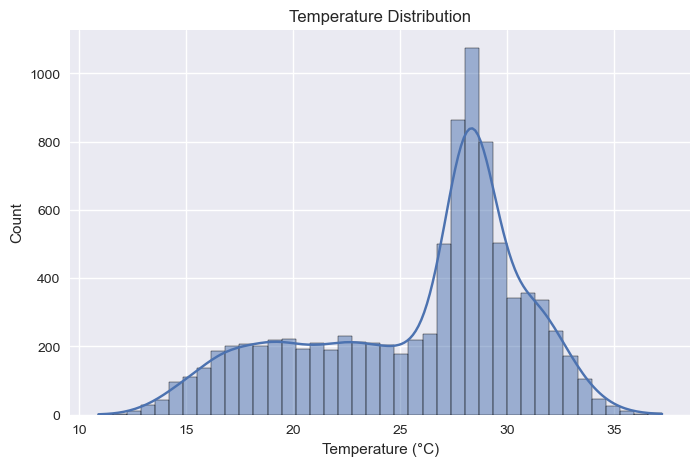

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["T2M"], bins=40, kde=True)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.show()

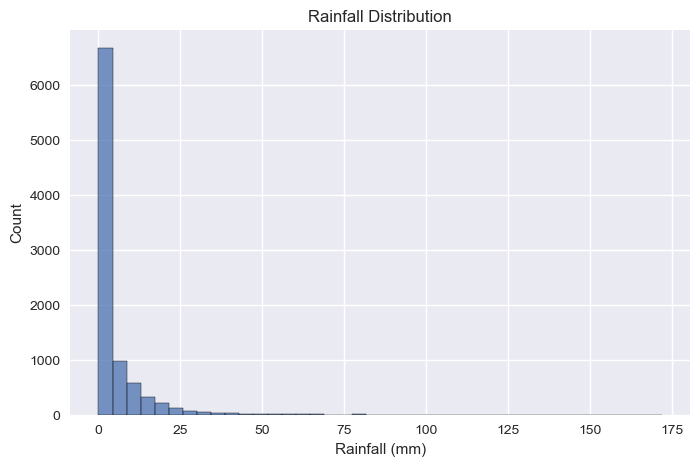

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["PRECTOTCORR"], bins=40)

plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.show()

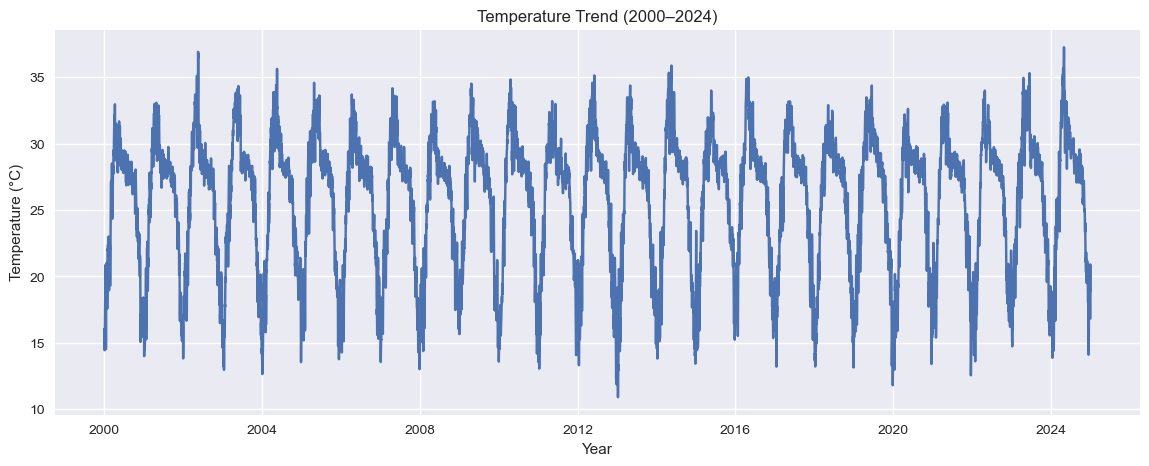

In [10]:
plt.figure(figsize=(14,5))

plt.plot(df["DATE"], df["T2M"])

plt.title("Temperature Trend (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")

plt.show()

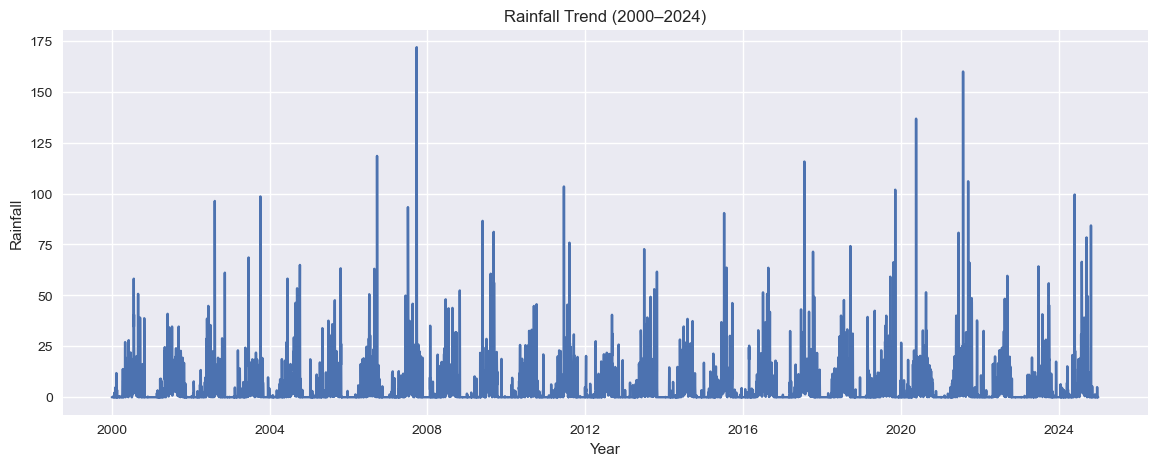

In [11]:
plt.figure(figsize=(14,5))

plt.plot(df["DATE"], df["PRECTOTCORR"])

plt.title("Rainfall Trend (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Rainfall")

plt.show()

In [12]:
df["YEAR"] = df["DATE"].dt.year

yearly = df.groupby("YEAR").mean()

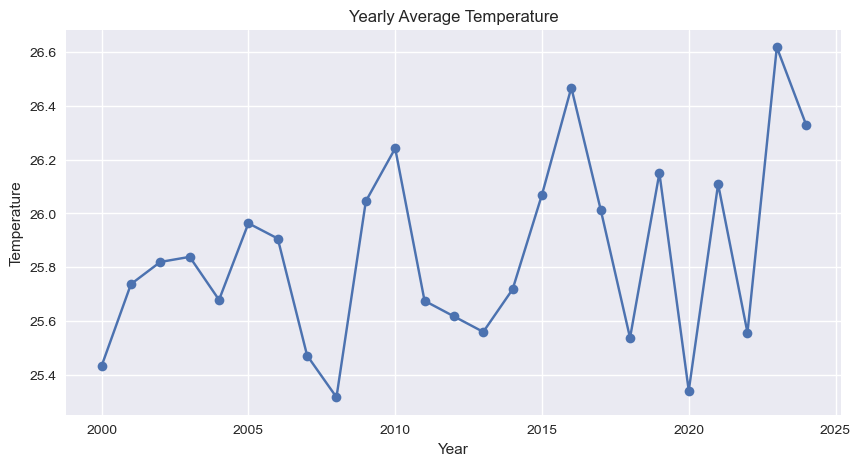

In [13]:
plt.figure(figsize=(10,5))

plt.plot(yearly.index, yearly["T2M"], marker="o")

plt.title("Yearly Average Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature")

plt.show()

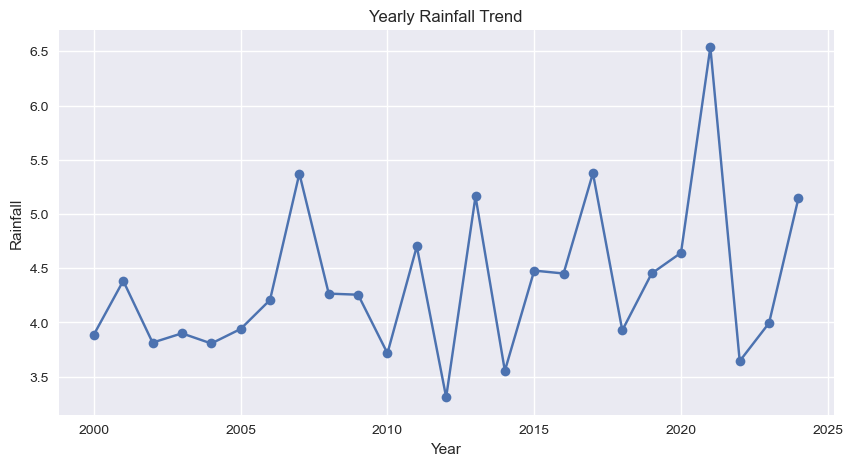

In [14]:
plt.figure(figsize=(10,5))

plt.plot(yearly.index, yearly["PRECTOTCORR"], marker="o")

plt.title("Yearly Rainfall Trend")
plt.xlabel("Year")
plt.ylabel("Rainfall")

plt.show()

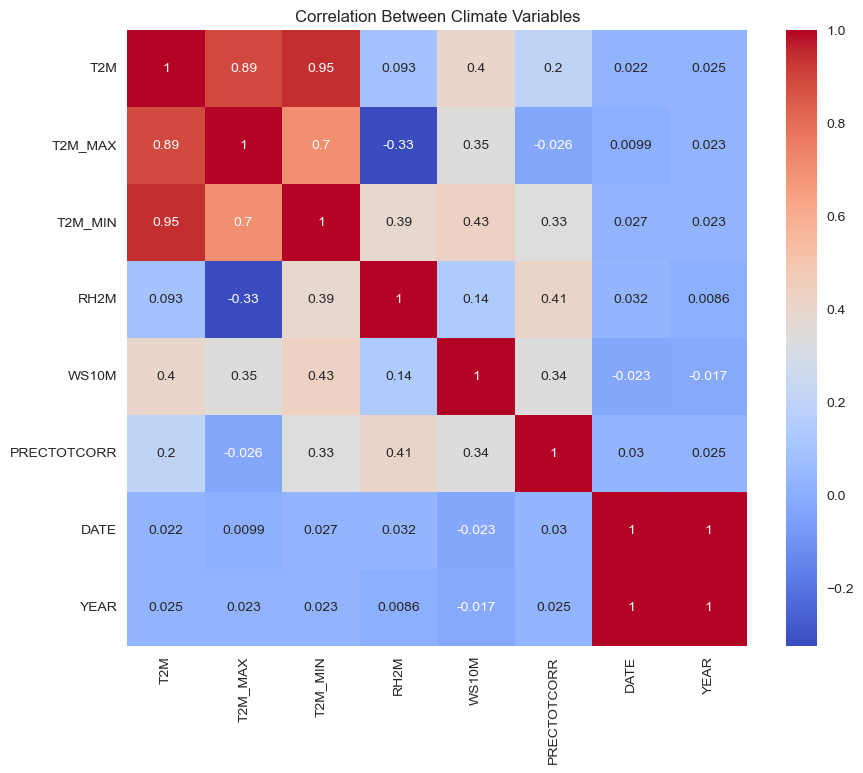

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Between Climate Variables")

plt.show()

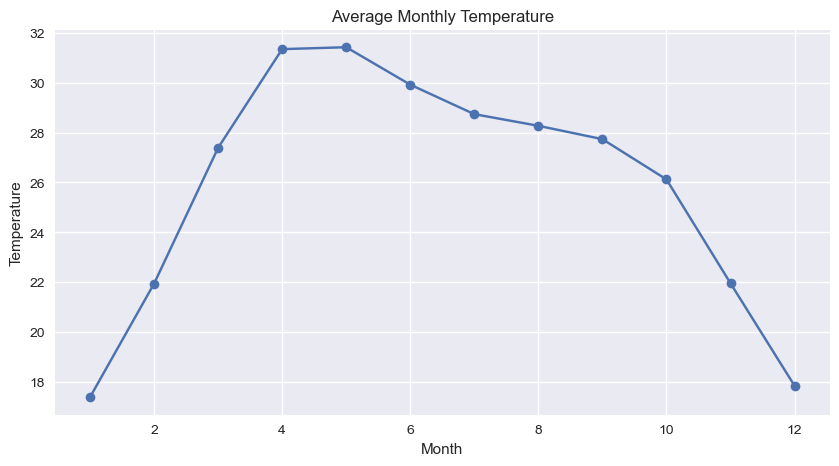

In [16]:
df["MONTH"] = df["DATE"].dt.month

monthly_temp = df.groupby("MONTH")["T2M"].mean()

plt.figure(figsize=(10,5))

plt.plot(monthly_temp.index, monthly_temp.values, marker="o")

plt.title("Average Monthly Temperature")

plt.xlabel("Month")
plt.ylabel("Temperature")

plt.show()

In [17]:
df["HEAVY_RAIN"] = df["PRECTOTCORR"] > 50

df["HEAVY_RAIN"].sum()

np.int64(60)

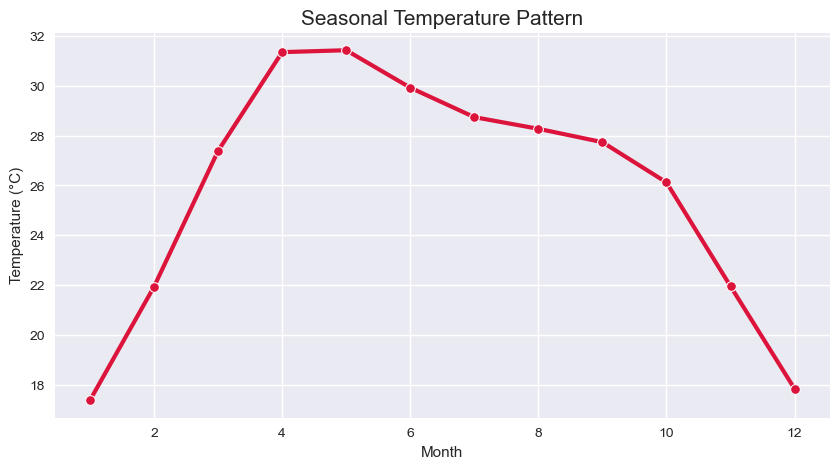

In [19]:
plt.figure(figsize=(10,5))

seasonal_temp = df.groupby("MONTH")["T2M"].mean()

sns.lineplot(
    x=seasonal_temp.index,
    y=seasonal_temp.values,
    marker="o",
    linewidth=3,
    color="crimson"
)

plt.title("Seasonal Temperature Pattern", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

plt.show()

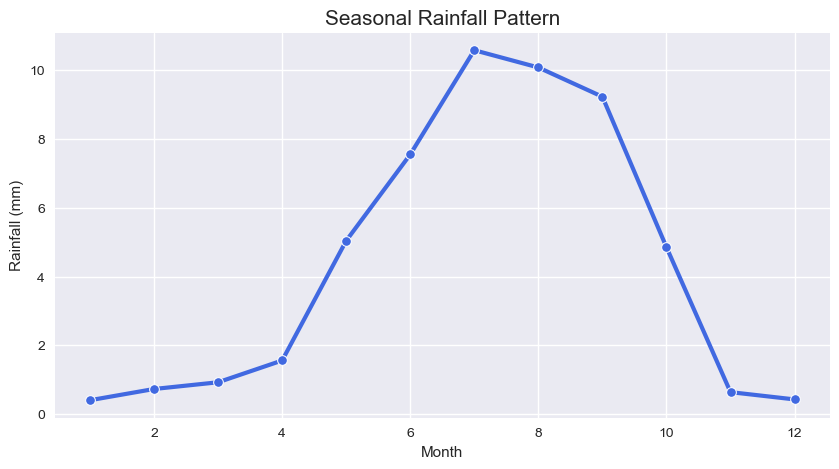

In [20]:
plt.figure(figsize=(10,5))

seasonal_rain = df.groupby("MONTH")["PRECTOTCORR"].mean()

sns.lineplot(
    x=seasonal_rain.index,
    y=seasonal_rain.values,
    marker="o",
    linewidth=3,
    color="royalblue"
)

plt.title("Seasonal Rainfall Pattern", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")

plt.show()

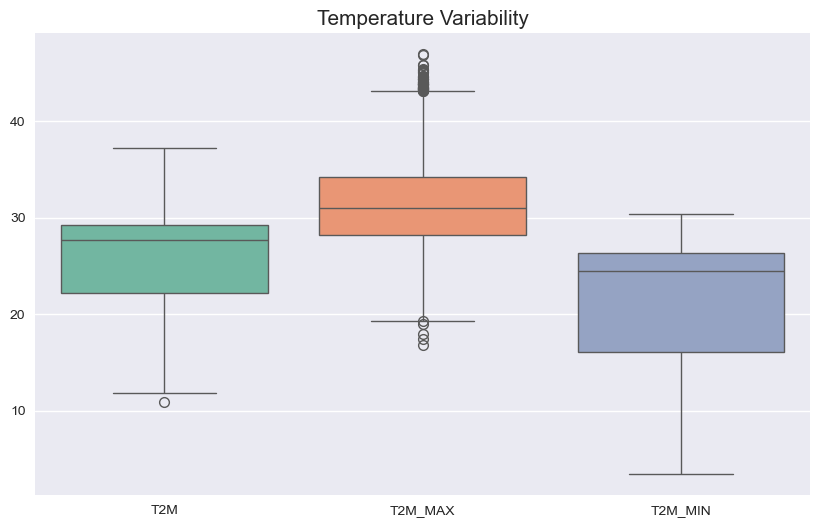

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df[["T2M","T2M_MAX","T2M_MIN"]],
    palette="Set2"
)

plt.title("Temperature Variability", fontsize=15)

plt.show()

C:\Users\avisw\AppData\Local\Temp\ipykernel_584\1914966380.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


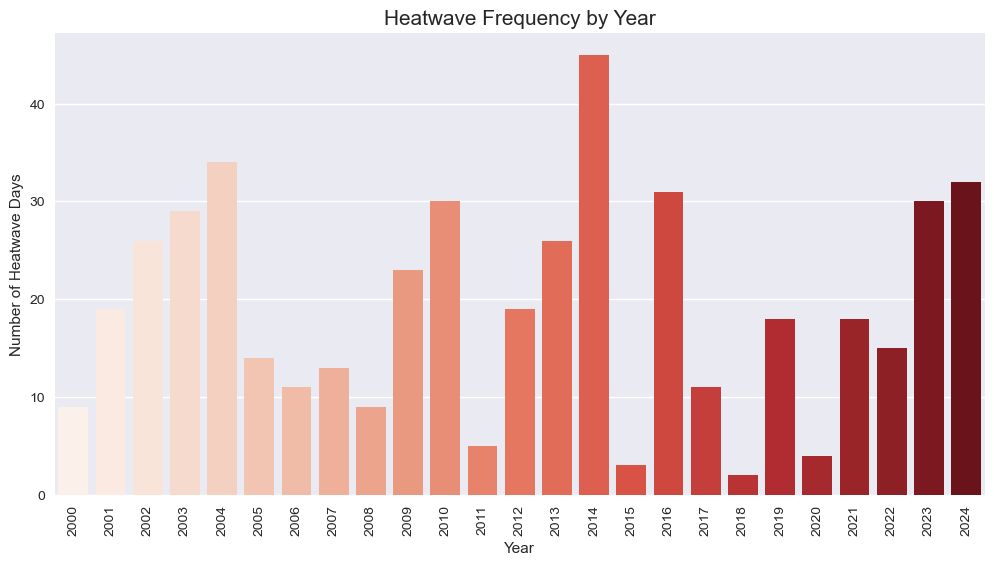

In [22]:
plt.figure(figsize=(12,6))

df["HEATWAVE"] = df["T2M_MAX"] >= 40

heatwave_year = df.groupby("YEAR")["HEATWAVE"].sum()

sns.barplot(
    x=heatwave_year.index,
    y=heatwave_year.values,
    palette="Reds"
)

plt.xticks(rotation=90)

plt.title("Heatwave Frequency by Year", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Number of Heatwave Days")

plt.show()

C:\Users\avisw\AppData\Local\Temp\ipykernel_584\2548723001.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


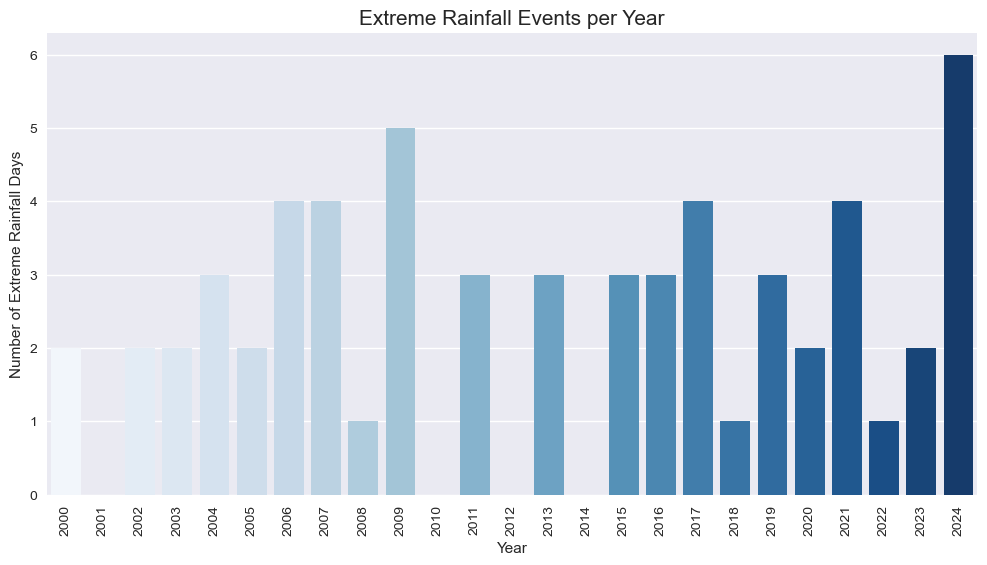

In [23]:
plt.figure(figsize=(12,6))

df["EXTREME_RAIN"] = df["PRECTOTCORR"] > 50

extreme_rain = df.groupby("YEAR")["EXTREME_RAIN"].sum()

sns.barplot(
    x=extreme_rain.index,
    y=extreme_rain.values,
    palette="Blues"
)

plt.xticks(rotation=90)

plt.title("Extreme Rainfall Events per Year", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Number of Extreme Rainfall Days")

plt.show()

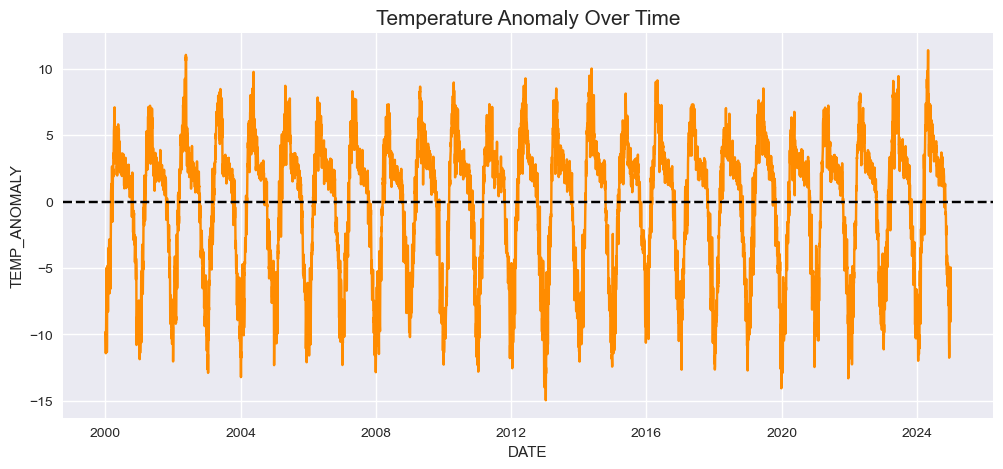

In [24]:
df["TEMP_ANOMALY"] = df["T2M"] - df["T2M"].mean()

plt.figure(figsize=(12,5))

sns.lineplot(
    x="DATE",
    y="TEMP_ANOMALY",
    data=df,
    color="darkorange"
)

plt.axhline(0, linestyle="--", color="black")

plt.title("Temperature Anomaly Over Time", fontsize=15)

plt.show()

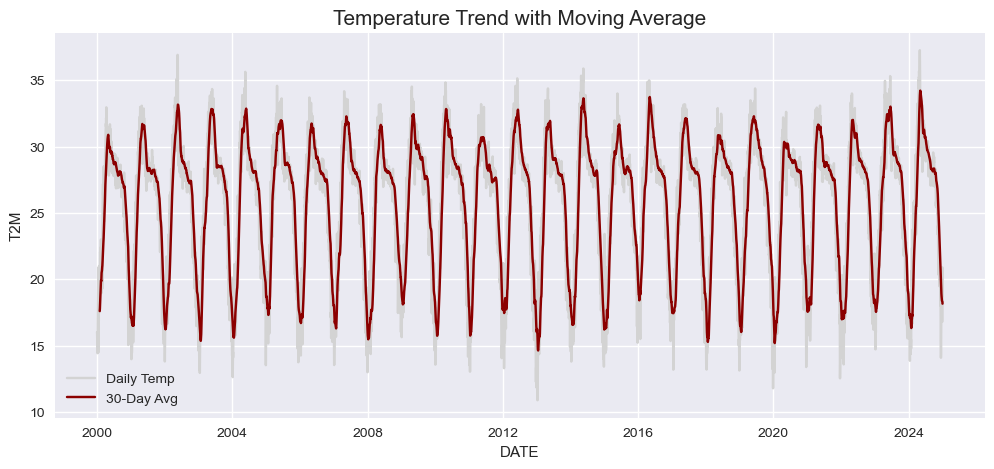

In [25]:
df["TEMP_MA30"] = df["T2M"].rolling(30).mean()

plt.figure(figsize=(12,5))

sns.lineplot(x="DATE", y="T2M", data=df, color="lightgray", label="Daily Temp")

sns.lineplot(x="DATE", y="TEMP_MA30", data=df, color="darkred", label="30-Day Avg")

plt.title("Temperature Trend with Moving Average", fontsize=15)

plt.legend()

plt.show()

c:\Users\avisw\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\avisw\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\avisw\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\avisw\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\avisw\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
c:\Users\avisw\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hu

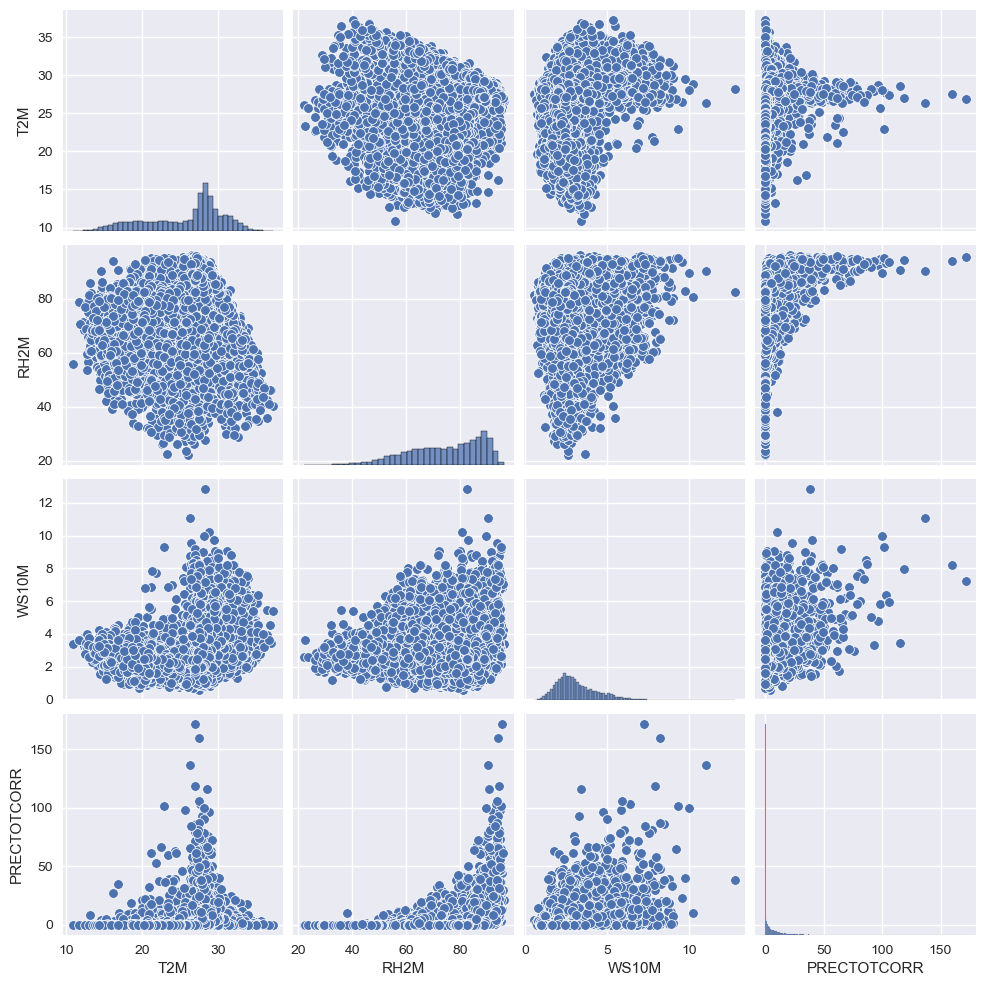

In [26]:
sns.pairplot(
    df[["T2M","RH2M","WS10M","PRECTOTCORR"]],
    palette="husl"
)

plt.show()

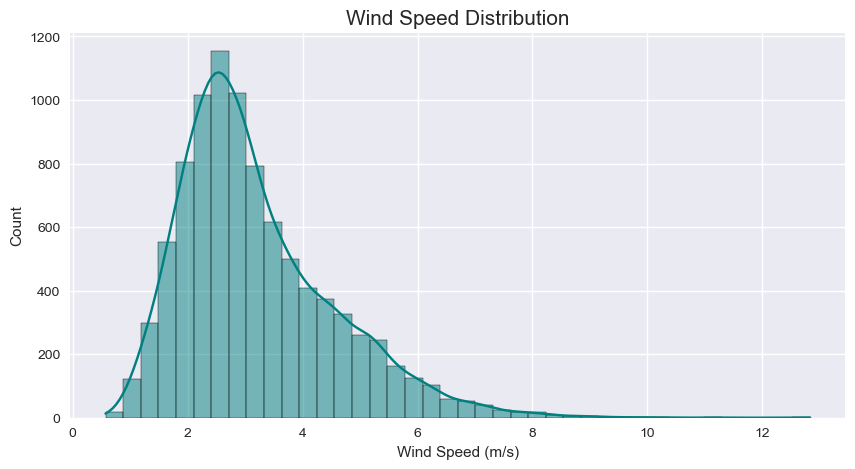

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["WS10M"],
    bins=40,
    kde=True,
    color="teal"
)

plt.title("Wind Speed Distribution", fontsize=15)
plt.xlabel("Wind Speed (m/s)")

plt.show()